# 과제 1 - 회귀분석
### delivery_eta_train.csv를 이용하여 delivery_eta_test의 배달시간을 예측하는 회귀모델 작성 --> 예측 수행

#### delivery_dataspec(데이터명세서) 참고
- 타깃(예측할 값)
- Delivery_Time_min : 주문 후 고객에게 도착하기까지 총 소요 시간(분)
- 특징(입력 변수) 예시
- Distance_km : 거리(km)
- Prep_Time_min : 음식 준비시간(분)
- Riders_Available : 주변 가용 라이더 수(명)
- Order_Queue : 매장 주문 적체(건)
- Weather : 날씨(맑음/비/눈/안개)
- Rain_mm : 강수량(mm)
- Temp_C : 기온(°C)
- Wind_mps : 풍속(m/s)
- Rush_Hour : 러시아워 여부(0/1)
- DayOfWeek : 요일(0=월 … 6=일)
- Time_Slot : 시간대(Morning/Lunch/Afternoon/Dinner/Night)
- Vehicle : 배달수단(Bike/Scooter/Car)
- Road_Type : 도로환경(Downtown/Suburban/Highway)
- Promo : 프로모션 여부(0/1)
- Tip_Level : 팁 수준(0~3)

In [1]:
# 커널 동작 확인
print("hello")

hello


In [ ]:
# ./data/delivery_eta_train.csv csv 불러오기
import pandas as pd
train = pd.read_csv("./data/delivery_eta_train.csv")
train.head()

,Order_ID,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Weather,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Time_Slot,Vehicle,Road_Type,Promo,Tip_Level,Delivery_Time_min
0,11502,6.1,15,9,3,Clear,0.0,14.9,1.2,1,1,Dinner,Scooter,Suburban,0,2,59.7
1,12587,7.5,14,15,6,Clear,0.0,14.3,3.0,0,0,Lunch,Scooter,Downtown,1,3,62.9
2,12654,17.6,24,14,4,Rain,4.8,27.0,3.2,0,0,Dinner,Bike,Downtown,0,2,134.7
3,11056,6.8,15,11,5,Clear,0.0,9.2,5.4,0,3,Night,Scooter,Highway,0,0,60.1
4,10706,19.6,16,11,2,Clear,0.0,11.8,2.6,1,2,Dinner,Bike,Downtown,0,1,149.2


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           4000 non-null   int64  
 1   Distance_km        4000 non-null   float64
 2   Prep_Time_min      4000 non-null   int64  
 3   Riders_Available   4000 non-null   int64  
 4   Order_Queue        4000 non-null   int64  
 5   Weather            4000 non-null   str    
 6   Rain_mm            4000 non-null   float64
 7   Temp_C             4000 non-null   float64
 8   Wind_mps           4000 non-null   float64
 9   Rush_Hour          4000 non-null   int64  
 10  DayOfWeek          4000 non-null   int64  
 11  Time_Slot          4000 non-null   str    
 12  Vehicle            4000 non-null   str    
 13  Road_Type          4000 non-null   str    
 14  Promo              4000 non-null   int64  
 15  Tip_Level          4000 non-null   int64  
 16  Delivery_Time_min  4000 non-null   

In [4]:
# ./data/delivery_eta_test.csv csv 불러오기
test = pd.read_csv("./data/delivery_eta_test.csv")
test.head()

,Order_ID,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Weather,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Time_Slot,Vehicle,Road_Type,Promo,Tip_Level,Delivery_Time_min
0,11702,16.4,14,7,2,Rain,2.8,34.3,2.2,0,2,Dinner,Car,Downtown,1,1,100.5
1,13294,5.3,16,14,4,Clear,0.0,7.0,2.6,1,2,Lunch,Bike,Downtown,0,3,66.3
2,12162,5.4,13,8,6,Rain,1.7,22.6,3.6,1,4,Dinner,Bike,Downtown,0,1,76.3
3,11137,20.0,17,3,1,Rain,4.8,28.0,3.0,1,2,Lunch,Scooter,Suburban,0,1,146.4
4,10988,7.4,16,11,0,Snow,8.1,21.4,2.8,0,0,Dinner,Scooter,Downtown,0,2,79.1


In [5]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           1000 non-null   int64  
 1   Distance_km        1000 non-null   float64
 2   Prep_Time_min      1000 non-null   int64  
 3   Riders_Available   1000 non-null   int64  
 4   Order_Queue        1000 non-null   int64  
 5   Weather            1000 non-null   str    
 6   Rain_mm            1000 non-null   float64
 7   Temp_C             1000 non-null   float64
 8   Wind_mps           1000 non-null   float64
 9   Rush_Hour          1000 non-null   int64  
 10  DayOfWeek          1000 non-null   int64  
 11  Time_Slot          1000 non-null   str    
 12  Vehicle            1000 non-null   str    
 13  Road_Type          1000 non-null   str    
 14  Promo              1000 non-null   int64  
 15  Tip_Level          1000 non-null   int64  
 16  Delivery_Time_min  1000 non-null   f

In [6]:
# 데이터 스케일링
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

target = "Delivery_Time_min"
id_col = "Order_ID"

X = train.drop(columns=[target])
y = train[target]

In [7]:
# 사용할 범주형/수치형 컬럼을 직접 지정합니다.
cat_cols = [
    "Weather",
    "Time_Slot",
    "Vehicle",
    "Road_Type",
]
num_cols = [
    "Distance_km",
    "Prep_Time_min",
    "Riders_Available",
    "Order_Queue",
    "Rain_mm",
    "Temp_C",
    "Wind_mps",
    "Rush_Hour",
    "DayOfWeek",
    "Promo",
    "Tip_Level",
]

# 실제 데이터에 있는 컬럼만 남깁니다.
cat_cols = [c for c in cat_cols if c in X.columns]
num_cols = [c for c in num_cols if c in X.columns and c != id_col]

preprocess = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

print(f"Categorical features: {cat_cols}")
print(f"Numeric features: {num_cols}")

Categorical features: ['Weather', 'Time_Slot', 'Vehicle', 'Road_Type']
Numeric features: ['Distance_km', 'Prep_Time_min', 'Riders_Available', 'Order_Queue', 'Rain_mm', 'Temp_C', 'Wind_mps', 'Rush_Hour', 'DayOfWeek', 'Promo', 'Tip_Level']


In [15]:
X.head()

,Order_ID,Distance_km,Prep_Time_min,Riders_Available,Order_Queue,Weather,Rain_mm,Temp_C,Wind_mps,Rush_Hour,DayOfWeek,Time_Slot,Vehicle,Road_Type,Promo,Tip_Level
0,11502,6.1,15,9,3,Clear,0.0,14.9,1.2,1,1,Dinner,Scooter,Suburban,0,2
1,12587,7.5,14,15,6,Clear,0.0,14.3,3.0,0,0,Lunch,Scooter,Downtown,1,3
2,12654,17.6,24,14,4,Rain,4.8,27.0,3.2,0,0,Dinner,Bike,Downtown,0,2
3,11056,6.8,15,11,5,Clear,0.0,9.2,5.4,0,3,Night,Scooter,Highway,0,0
4,10706,19.6,16,11,2,Clear,0.0,11.8,2.6,1,2,Dinner,Bike,Downtown,0,1


In [8]:
# train/test 데이터 분리
from sklearn.model_selection import train_test_split

X = train.drop(columns=[target])
y = train[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

if target in test.columns:
    X_test = test.drop(columns=[target])
    y_test = test[target]
else:
    X_test = test.copy()
    y_test = None

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (3200, 16) Val: (800, 16) Test: (1000, 16)


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = Pipeline([
    ("preprocess", preprocess),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1,
    )),
])

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [10]:
y_val_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print(f"Val MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")
print(pd.DataFrame({"actual": y_val[:10], "pred": y_val_pred[:10]}))

Val MAE: 4.52 | RMSE: 5.68 | R²: 0.933
      actual       pred
555     31.4  33.930450
3491    51.8  44.719795
527     43.0  45.013679
3925    60.2  65.137532
2989    79.9  69.144791
70      64.2  63.910744
1756    93.0  93.903401
211     77.5  77.690629
196     59.6  65.796047
803     51.7  59.696035


In [11]:
y_test_pred = model.predict(X_test)

print("Test predictions:")
print(pd.Series(y_test_pred).describe()[["min", "max", "mean", "50%"]].rename({"50%": "median"}))

if y_test is not None:
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    print(f"Test MAE: {test_mae:.2f} | RMSE: {test_rmse:.2f} | R²: {test_r2:.3f}")

Test predictions:
min        28.572098
max       145.477949
mean       66.617589
median     63.011546
dtype: float64
Test MAE: 4.48 | RMSE: 5.59 | R²: 0.933


In [12]:
order_ids = X_test[id_col] if id_col in X_test.columns else test[id_col]

submission = pd.DataFrame({
    id_col: order_ids,
    target: y_test_pred,
})

output_file = "./data/delivery_prediction_result.csv"
submission.to_csv(output_file, index=False)

print("Saved:", output_file)
submission.head()

Saved: ./data/delivery_prediction_result.csv


,Order_ID,Delivery_Time_min
0,11702,112.948518
1,13294,66.385055
2,12162,70.419642
3,11137,140.479448
4,10988,89.492429


               feature  importance
0          Distance_km    0.797519
1        Prep_Time_min    0.051298
11       Weather_Clear    0.030547
7            Rush_Hour    0.024067
14        Weather_Snow    0.018690
2     Riders_Available    0.011911
3          Order_Queue    0.011799
5               Temp_C    0.007553
6             Wind_mps    0.007549
4              Rain_mm    0.007288
20        Vehicle_Bike    0.006444
23  Road_Type_Downtown    0.005591
8            DayOfWeek    0.003909
10           Tip_Level    0.003715
24   Road_Type_Highway    0.002796


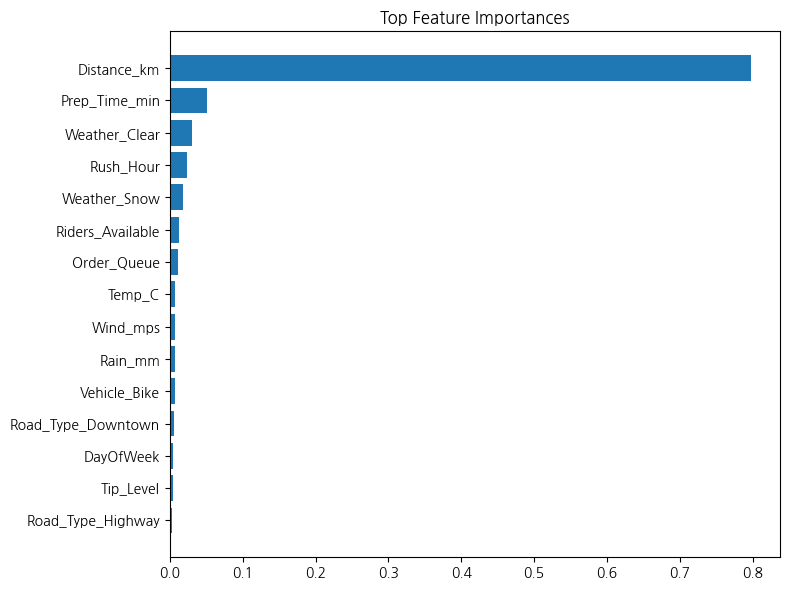

In [13]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

feature_names = num_cols + model.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()
importances = model.named_steps["regressor"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

print(feature_importance_df.head(15))

plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df.head(15)["feature"], feature_importance_df.head(15)["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()